### Task 1: Exploratory Data Analysis (EDA)

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [56]:
df=pd.read_csv('Pharma_Industry.csv')

In [57]:
df.shape

(500, 6)

In [58]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [60]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [61]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [62]:
df.duplicated().sum()

0

In [64]:
print("Target Variable Distribution:")
print(df['Drug Response'].value_counts())

Target Variable Distribution:
Drug Response
1    260
0    240
Name: count, dtype: int64


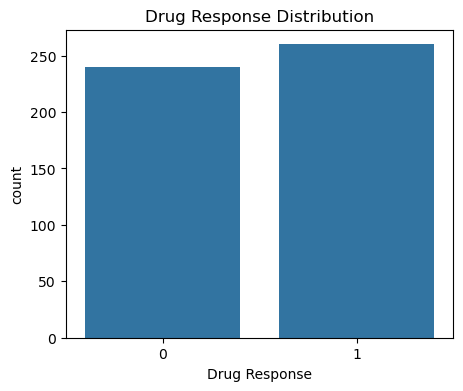

In [65]:
plt.figure(figsize=(5,4))
sns.countplot(x='Drug Response', data=df)
plt.title("Drug Response Distribution")
plt.show()

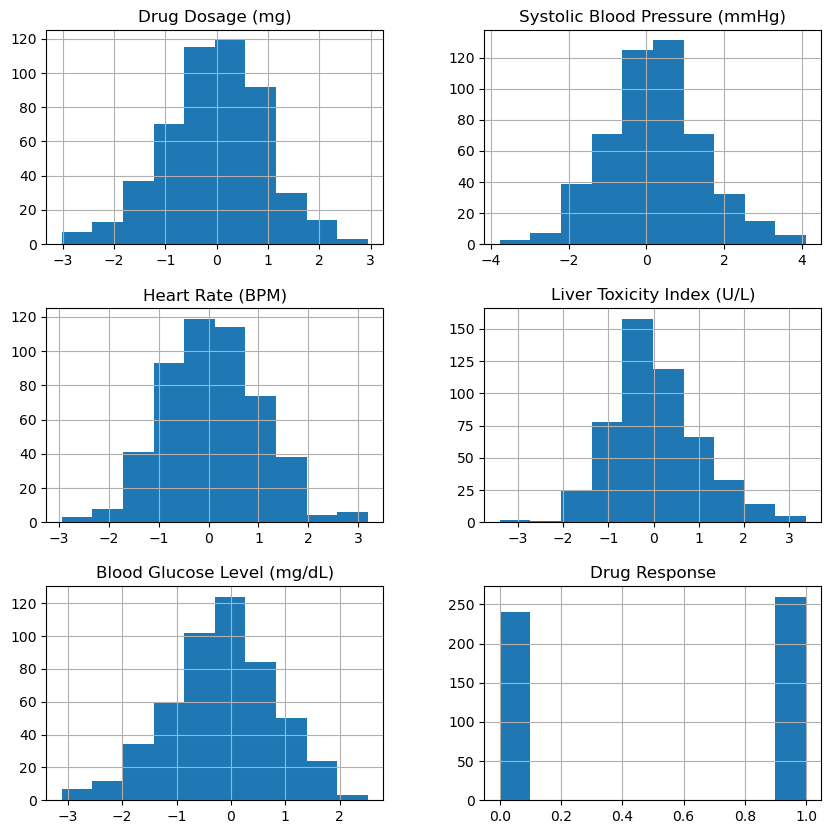

In [66]:
df.hist(figsize=(10, 10))  # Plot histograms for all features
plt.show()

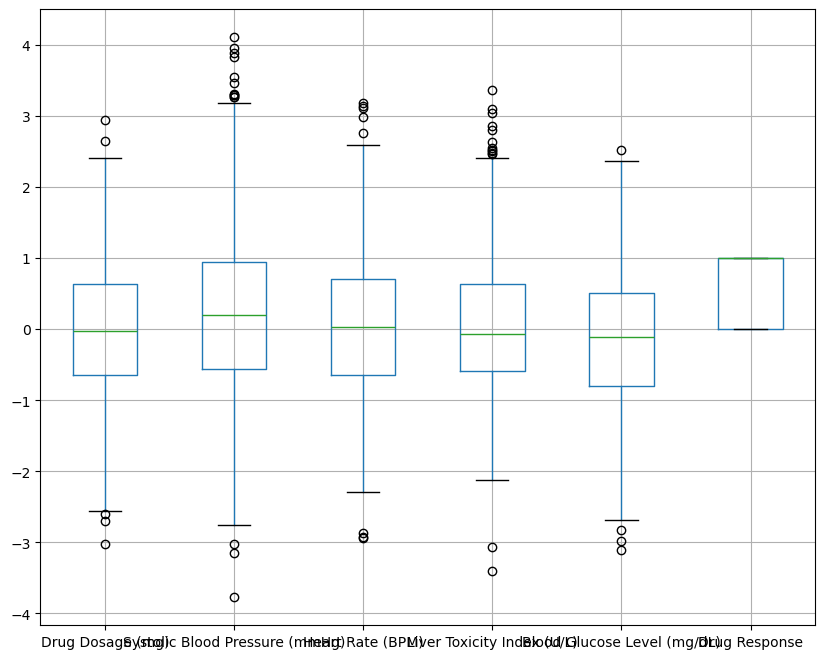

In [67]:
#checking outliers by using boxplot
plt.figure(figsize=(10,8))
df.boxplot()
plt.show()

In [68]:
#outlier capping 
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    high_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else high_extreme if x>high_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

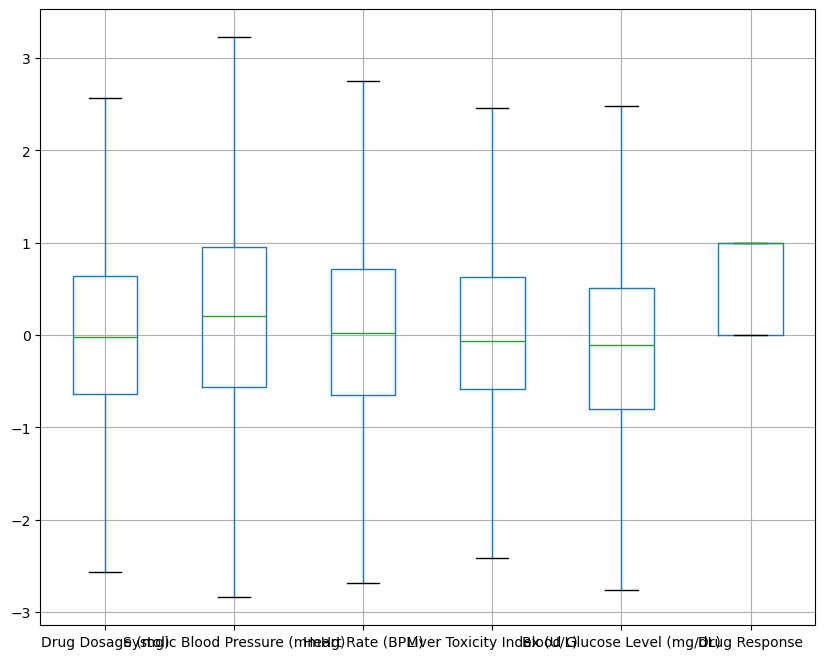

In [69]:
plt.figure(figsize=(10,8))
df.boxplot()
plt.show()

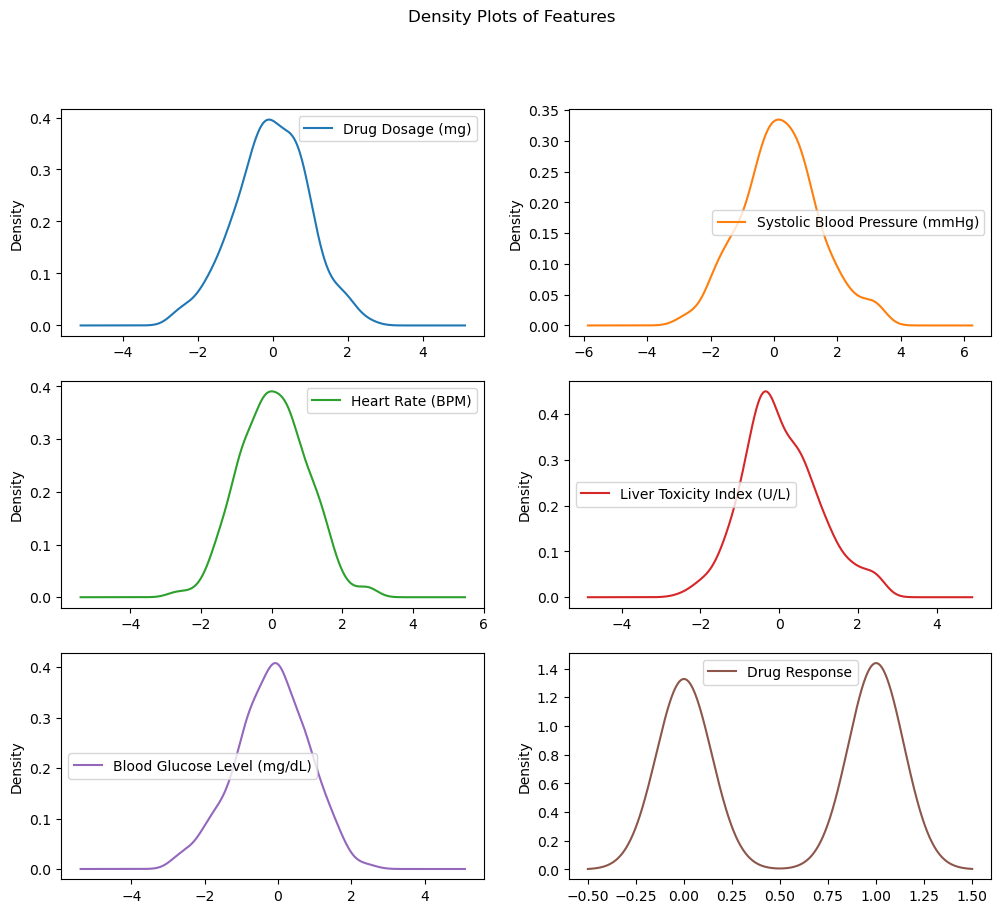

In [70]:
df.plot(kind='density', subplots=True, layout=(3,2),figsize=(12,10), sharex=False)
plt.suptitle("Density Plots of Features")
plt.show()

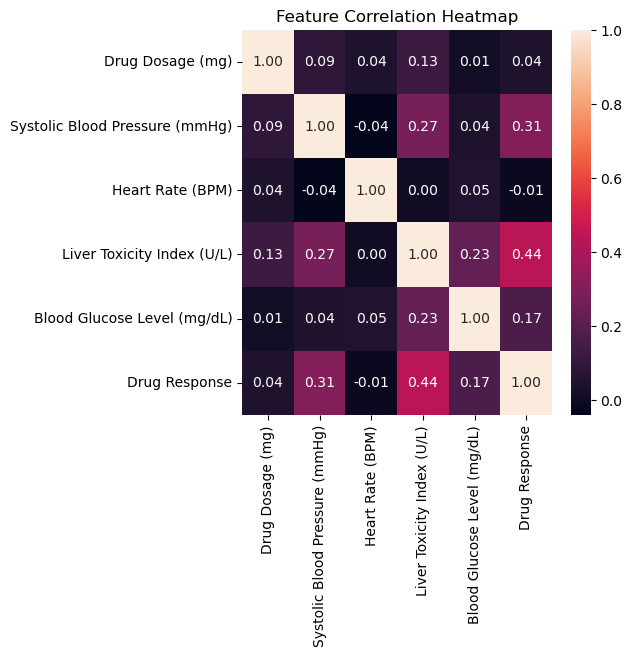

In [71]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(),annot=True,fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

### Task 2: Data Preprocessing

In [72]:
print(df.dtypes)

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object


In [73]:
# Since this dataset contains only numerical features,
# no categorical encoding is required.

In [74]:
# Features (Independent Variables)
features= df.drop('Drug Response', axis=1)
# Target Variable (Dependent Variable)
target= df[['Drug Response']]

In [78]:
# splitting the data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=10)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 5)
(100, 5)
(400, 1)
(100, 1)


### Task 3: Data Visualization

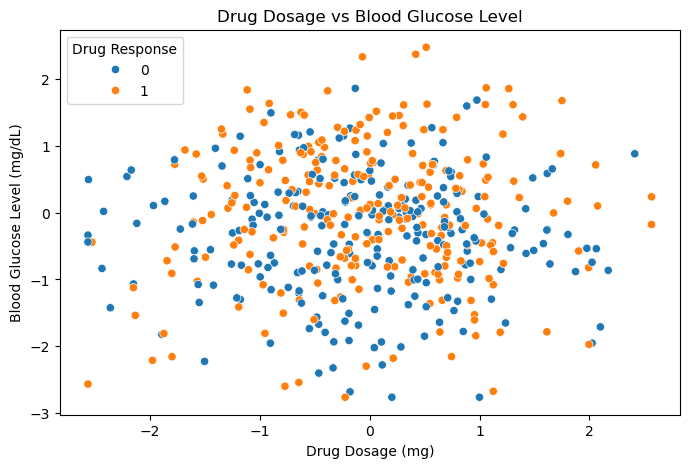

In [76]:
#scatter plot relation
plt.figure(figsize=(8,5))
sns.scatterplot(x='Drug Dosage (mg)',y='Blood Glucose Level (mg/dL)',hue='Drug Response',data=df)
plt.title("Drug Dosage vs Blood Glucose Level")
plt.show()

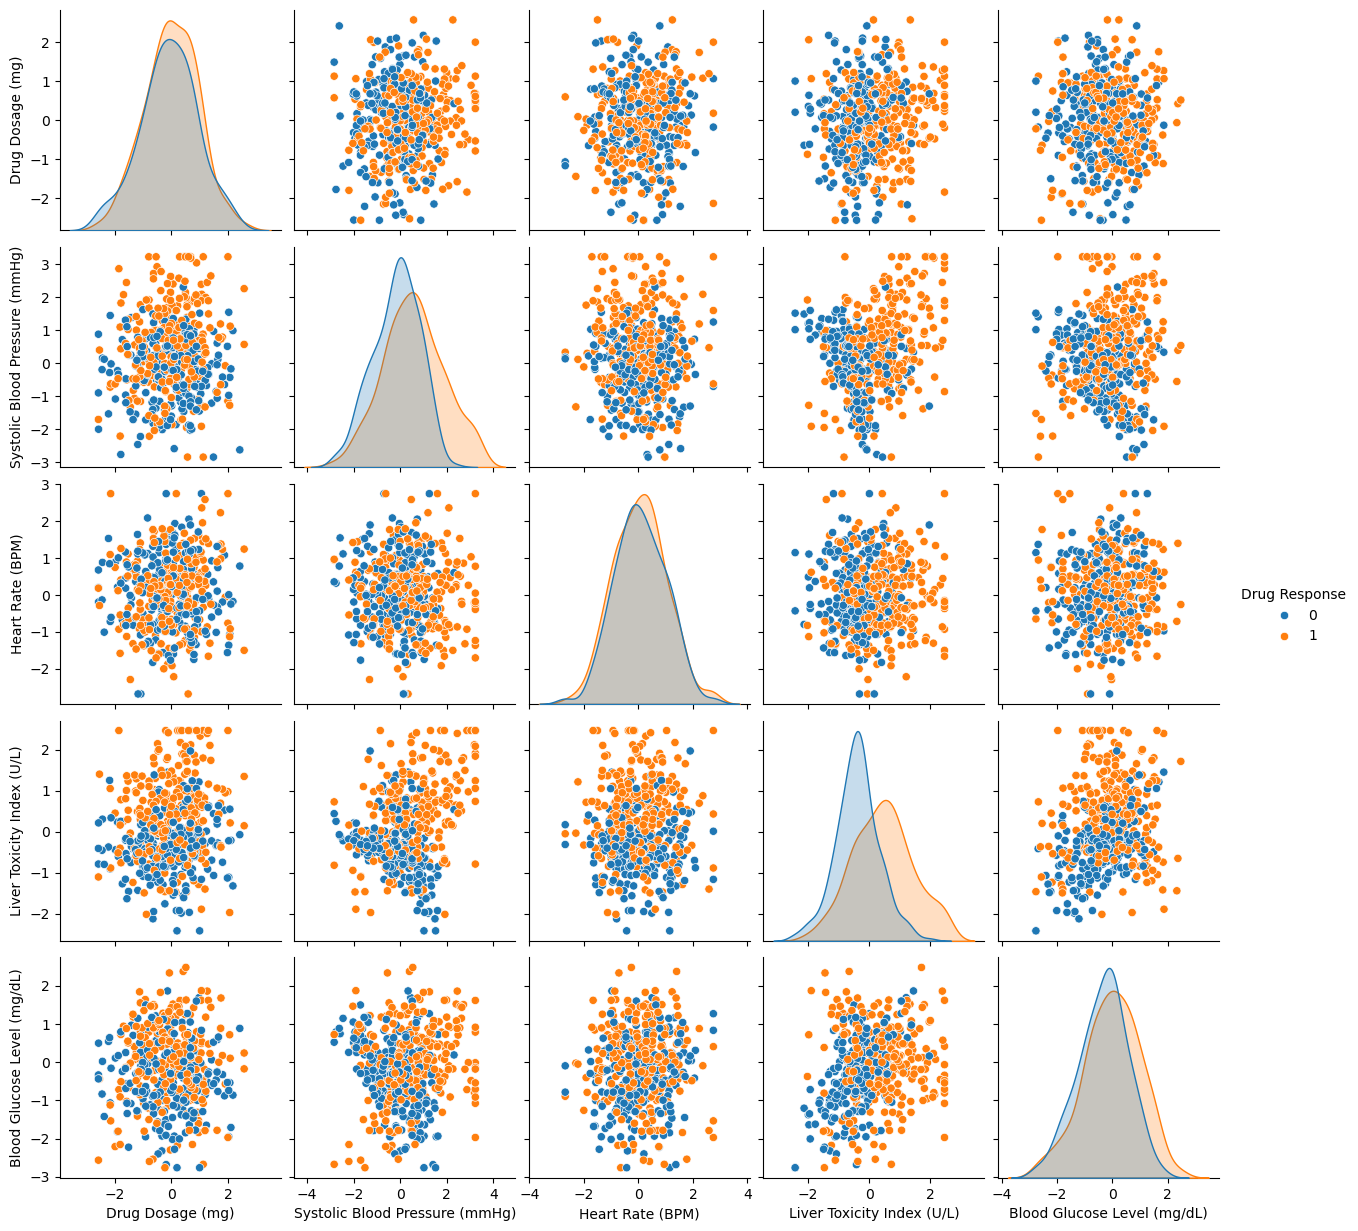

In [77]:
# pair plot
sns.pairplot(df, hue='Drug Response')
plt.show()

In [79]:
# Unique class labels
df['Drug Response'].unique()

array([1, 0], dtype=int64)

In [80]:
# Number of samples in each class
df['Drug Response'].value_counts()

Drug Response
1    260
0    240
Name: count, dtype: int64

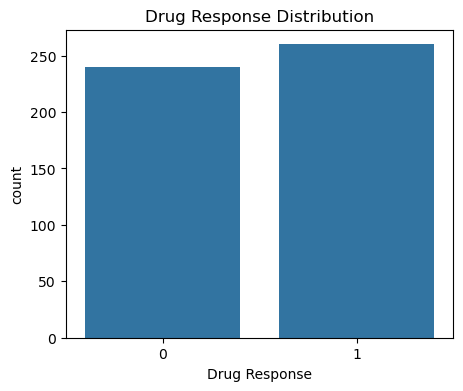

In [81]:
# class distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Drug Response', data=df)
plt.title("Drug Response Distribution")
plt.show()

### Task 4: SVM Implementation

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

In [27]:
svm_model = SVC(kernel='linear',C=2)
svm_model.fit(x_train, y_train)

SVC(C=2, kernel='linear')

In [28]:
y_pred = svm_model.predict(x_test)

In [29]:
# Model Evaluation
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

# Precision
precision = precision_score(y_test, y_pred)
print("Precision :", precision)

# Recall
recall = recall_score(y_test, y_pred)
print("Recall :", recall)

# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1-Score :", f1)

#Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.68
Precision : 0.7346938775510204
Recall : 0.6545454545454545
F1-Score : 0.6923076923076923

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.71      0.67        45
           1       0.73      0.65      0.69        55

    accuracy                           0.68       100
   macro avg       0.68      0.68      0.68       100
weighted avg       0.69      0.68      0.68       100


Confusion Matrix:

[[32 13]
 [19 36]]


### Task 5: Visualization of SVM Results


confusion matrix:



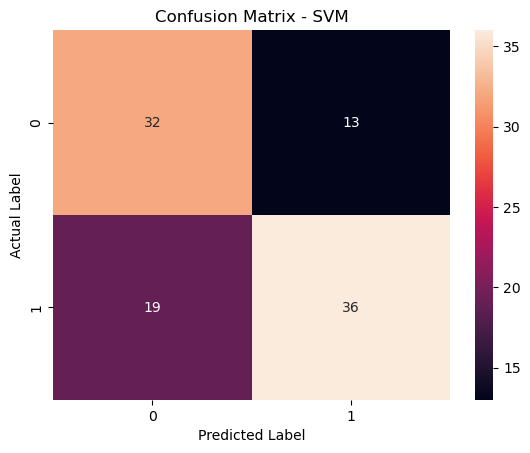

In [30]:
print('\nconfusion matrix:\n')
con=confusion_matrix(y_test,y_pred)
sns.heatmap(con,annot=True)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

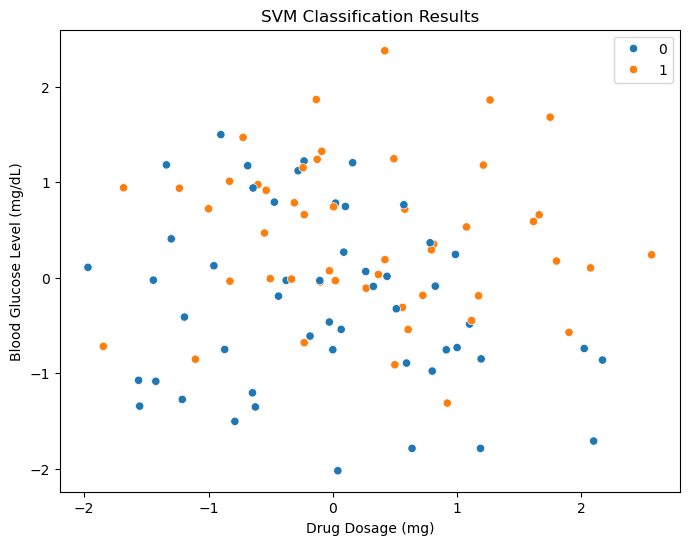

In [31]:
#visulaize svm classification results
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=x_test['Drug Dosage (mg)'],
    y=x_test['Blood Glucose Level (mg/dL)'],
    hue=y_pred
)

plt.title('SVM Classification Results')
plt.xlabel('Drug Dosage (mg)')
plt.ylabel('Blood Glucose Level (mg/dL)')

plt.show()

### Task 6: Parameter Tuning and Optimization

In [82]:
# Step 1: Experiment with different SVM hyperparameters
from sklearn.model_selection import GridSearchCV

In [41]:
param_grid = {'C': [0.1, 1, 10, 50], 'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf', 'poly', 'linear','sigmoid']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)
grid.fit(x_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.550 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.550 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.525 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.550 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.575 total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.725 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.675 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.713 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.688 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.713 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.675 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 50], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'poly', 'linear', 'sigmoid']},
             verbose=3)

In [42]:
print("Best Parameters:", grid.best_params_)
print("Best Estimator:", grid.best_estimator_)

Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Estimator: SVC(C=10, gamma=0.1)


In [43]:
# Retrain SVM with best parameters
best_svm_model = grid.best_estimator_
best_svm_model.fit(x_train, y_train)

SVC(C=10, gamma=0.1)

In [44]:
# Evaluate model performance
y_pred_best = best_svm_model.predict(x_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print("Accuracy (Best Parameters):", accuracy_best)
print("Classification Report (Best Parameters):\n", classification_report(y_test, y_pred_best))

Accuracy (Best Parameters): 0.75
Classification Report (Best Parameters):
               precision    recall  f1-score   support

           0       0.69      0.80      0.74        45
           1       0.81      0.71      0.76        55

    accuracy                           0.75       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.76      0.75      0.75       100



### Task 7: Comparison and Analysis

In [50]:
# Linear kernal
linear_model = SVC(kernel='linear')

linear_model.fit(x_train, y_train)

linear_pred = linear_model.predict(x_test)

linear_acc = accuracy_score(y_test, linear_pred)


In [52]:
# Polynomial kernel
poly_model = SVC(kernel='poly')

poly_model.fit(x_train, y_train)

poly_pred = poly_model.predict(x_test)

poly_acc = accuracy_score(y_test, poly_pred)


In [53]:
# rbf kernel

rbf_model = SVC(kernel='rbf')

rbf_model.fit(x_train, y_train)

rbf_pred = rbf_model.predict(x_test)

rbf_acc = accuracy_score(y_test, rbf_pred)

In [ ]:
# sigmoid kernel
sigmoid_model = SVC(kernel='sigmoid')

sigmoid_model.fit(x_train, y_train)

sigmoid_pred = sigmoid_model.predict(x_test)

sigmoid_acc = accuracy_score(y_test, sigmoid_pred)

In [ ]:
# 1.Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

In [54]:

comparison = pd.DataFrame({
    'Kernel': ['Linear', 'Polynomial', 'RBF','Sig],
    'Accuracy': [linear_acc, poly_acc, rbf_acc]
})

print(comparison)

       Kernel  Accuracy
0      Linear      0.68
1  Polynomial      0.73
2         RBF      0.72


In [83]:
# 2.Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

In [84]:
# 3.Discuss practical implications of SVM in real-world classification tasks.